# Trend classification with fashion-CLIP and Qdrant k-NN

[ARCHITECTURE.md §3.5](../ARCHITECTURE.md#35-retrieval--fashionclip--qdrant-k-nn-trend-classifier).

Each labeled reference image produces two embeddings from fashion-CLIP:

- `image_vec`: the image encoder applied to the photo
- `caption_vec`: the text encoder applied to the LLM-normalized attribute description

Both vectors are stored as named vectors on the same Qdrant point, with the trend label in the payload. At inference time, a query image (and optionally a query text) is embedded by the same two encoders, two cosine searches run, and the top-k labeled neighbors vote on the trend.

This notebook reports leave-one-out evaluation on 67 labeled reference images across three trends: `mob_wife`, `office_siren`, `quiet_luxury`.

**Sections**

1. Setup
2. Reference images by class
3. Load embedder and vector store
4. Leave-one-out evaluation: majority vs Shepard vote
5. Sample queries with their top-5 neighbors
6. Confusion matrices
7. UMAP of the image embeddings
8. Calibration: reliability diagram
9. Image-only summary
10. Hybrid retrieval (image + text)
11. α sensitivity sweep
12. Final results
13. Example queries using the strongest setup

## 1. Setup

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

# Make src/ importable when running from notebooks/
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR
sys.path.insert(0, str(PROJECT_ROOT / "src"))


import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

from fashion_forensics.config import settings
from fashion_forensics.retrieval.classifier import predict_trend
from fashion_forensics.retrieval.embedder import FashionClipEmbedder
from fashion_forensics.retrieval.qdrant_store import TrendQdrantStore

LABELED_ROOT = PROJECT_ROOT / "data" / "02_reference_corpus" / "labeled"
IMAGE_EXTS = {".jpg", ".jpeg", ".webp", ".png"}

# Color palette for plots: shades of green, lime, and brown
COLOR_BY_CLASS = {
    "mob_wife": "#8D6E63",  # warm brown
    "office_siren": "#1B5E20",  # forest green
    "quiet_luxury": "#9CCC65",  # sage / lime
}
COLOR_CORRECT = "#2E7D32"  # forest green (same-class match, correct prediction)
COLOR_WRONG = "#A1887F"  # muted brown (intruder, wrong prediction)
COLOR_DIAG = "#BCAAA4"  # warm grey-brown (baselines, diagonal lines)
COLOR_PRIMARY = "#388E3C"  # mid green (primary metric line)
COLOR_ACCENT = "#9ACD32"  # lime (secondary metric)
CMAP_HEAT = "Greens"

print(f"Project root: {PROJECT_ROOT}")
print(f"Labeled root: {LABELED_ROOT}")

Project root: /Users/esosaimafidon/Documents/Documents - Esosa’s MacBook Air/GitHub/how-fast-is-fashion
Labeled root: /Users/esosaimafidon/Documents/Documents - Esosa’s MacBook Air/GitHub/how-fast-is-fashion/data/02_reference_corpus/labeled


## 2. Reference images by class

In [2]:
def discover_refs():
    paths, labels = [], []
    for trend_dir in sorted(LABELED_ROOT.iterdir()):
        if not trend_dir.is_dir():
            continue
        for p in sorted(trend_dir.iterdir()):
            if p.suffix.lower() in IMAGE_EXTS:
                paths.append(p)
                labels.append(trend_dir.name)
    return paths, labels


paths, labels = discover_refs()
classes = sorted(set(labels))
print(f"Total references: {len(paths)}  |  Classes: {classes}")
for c in classes:
    print(f"  {c}: {labels.count(c)} images")

Total references: 67  |  Classes: ['mob_wife', 'office_siren', 'quiet_luxury']
  mob_wife: 18 images
  office_siren: 24 images
  quiet_luxury: 25 images


### One example per class

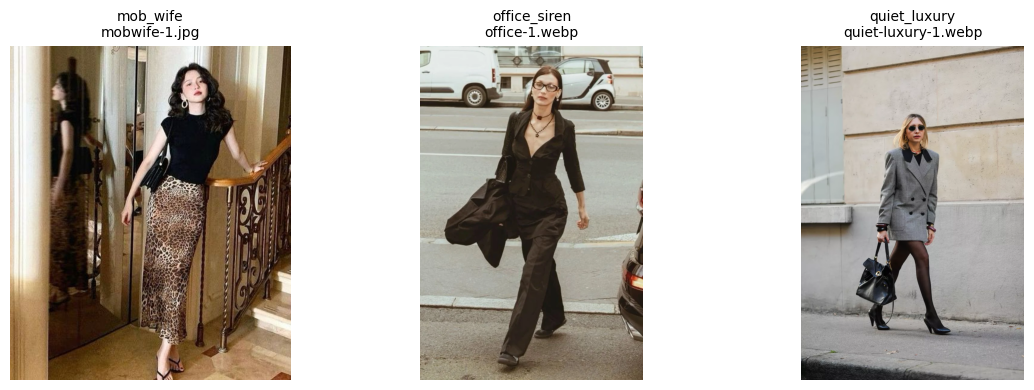

In [3]:
fig, axes = plt.subplots(1, len(classes), figsize=(4 * len(classes), 4))
for ax, cls in zip(axes, classes):
    # first image of each class
    example_path = next(p for p, lbl in zip(paths, labels) if lbl == cls)
    ax.imshow(Image.open(example_path).convert("RGB"))
    ax.set_title(f"{cls}\n{example_path.name}", fontsize=10)
    ax.axis("off")
plt.tight_layout()
plt.show()

## 3. Load embedder and vector store

`FashionClipEmbedder` wraps `patrickjohncyh/fashion-clip` (image and text encoders, 512-dim shared space). `TrendQdrantStore` reads a local on-disk Qdrant collection populated by `scripts/embed_reference_corpus.py`.

In [4]:
embedder = FashionClipEmbedder(model_name=settings.fashion_clip_model)
store = TrendQdrantStore(
    path=PROJECT_ROOT / settings.qdrant_path,
    collection_name=settings.qdrant_collection,
    embedding_dim=embedder.embedding_dim,
)
assert store.count() == len(paths), (
    f"Qdrant has {store.count()} points but found {len(paths)} refs on disk. "
    "Re-run: python scripts/embed_reference_corpus.py"
)
print(f"Qdrant collection '{settings.qdrant_collection}' ready with {store.count()} points")

2026-04-29 19:48:41.421 | INFO     | fashion_forensics.retrieval.embedder:__init__:49 - Loading patrickjohncyh/fashion-clip on mps


Qdrant collection 'trends_ref_v2' ready with 67 points


## 4. Leave-one-out evaluation: majority vs Shepard vote

For each reference image, query Qdrant against the other 58, take the top 5 neighbors, vote, compare to the ground-truth label. Two voting methods:

- **Majority vote.** Count neighbor labels, pick the mode. Ties broken by insertion order.
- **Shepard vote.** Each neighbor contributes its cosine similarity to its class's score. Class with the most weighted mass wins. Confidence is the winner's share of total similarity.

This section uses image-only retrieval (`search_mode="image"`). The text and hybrid modes are introduced in section 10.

In [5]:
K = 5


def run_loocv(vote_method):
    preds, confs = [], []
    for path in paths:
        pred = predict_trend(
            image_path=path,
            embedder=embedder,
            store=store,
            k=K,
            vote_method=vote_method,
            search_mode="image",  # INTERIM: image-only until path-B (caption_vec) ships
            exclude_filenames=[path.name],
        )
        preds.append(pred.trend_pred)
        confs.append(pred.confidence)
    return np.array(preds), np.array(confs)


preds_maj, confs_maj = run_loocv("majority")
preds_shep, confs_shep = run_loocv("shepard")
labels_arr = np.array(labels)
print("LOOCV complete.")

LOOCV complete.


In [6]:
from sklearn.metrics import confusion_matrix, f1_score


def ece(conf, correct, n_bins=10):
    edges = np.linspace(0, 1, n_bins + 1)
    e = 0.0
    for lo, hi in zip(edges[:-1], edges[1:]):
        mask = (conf > lo) & (conf <= hi)
        if mask.any():
            e += (mask.sum() / len(conf)) * abs(conf[mask].mean() - correct[mask].mean())
    return float(e)


def metrics(preds, confs):
    correct = (preds == labels_arr).astype(int)
    return {
        "accuracy": correct.mean(),
        "macro_f1": f1_score(labels_arr, preds, labels=classes, average="macro"),
        "ece": ece(confs, correct),
    }


import pandas as pd

summary = pd.DataFrame(
    {
        "majority": metrics(preds_maj, confs_maj),
        "shepard": metrics(preds_shep, confs_shep),
    }
).round(3)
summary

,majority,shepard
accuracy,0.866,0.866
macro_f1,0.866,0.866
ece,0.163,0.070


## 5. Sample queries with their top-5 neighbors

Each query image is rendered with its top-5 retrieved neighbors. Border colors:

- Green = correct prediction or same-class neighbor
- Brown = wrong prediction or wrong-class neighbor

In [7]:
def render_query_and_neighbors(query_path, true_label, vote_method="shepard"):
    pred = predict_trend(
        image_path=query_path,
        embedder=embedder,
        store=store,
        k=5,
        vote_method=vote_method,
        search_mode="image",
        exclude_filenames=[query_path.name],
    )
    correct = pred.trend_pred == true_label
    border = COLOR_CORRECT if correct else COLOR_WRONG
    label_word = "CORRECT" if correct else "WRONG"

    fig, axes = plt.subplots(1, 6, figsize=(20, 3.5))
    # Query image
    axes[0].imshow(Image.open(query_path).convert("RGB"))
    axes[0].set_title(
        f"QUERY\ntrue={true_label}\npred={pred.trend_pred} ({pred.confidence:.2f})\n[{label_word}]",
        fontsize=9,
        color=border,
    )
    axes[0].axis("off")
    for spine in axes[0].spines.values():
        spine.set_edgecolor(border)
        spine.set_linewidth(4)
    # Top-5 neighbors
    for i, neighbor in enumerate(pred.matched_refs, start=1):
        n_path = next(p for p, lbl in zip(paths, labels) if p.name == neighbor["filename"])
        axes[i].imshow(Image.open(n_path).convert("RGB"))
        same = neighbor["trend"] == true_label
        mark = "✓" if same else "✗"
        c = COLOR_CORRECT if same else COLOR_WRONG
        axes[i].set_title(
            f"#{i} {mark} sim={neighbor['score']:.2f}\n{neighbor['trend']}\n{neighbor['filename'][:18]}",
            fontsize=8,
            color=c,
        )
        axes[i].axis("off")
    plt.suptitle(f"vote_method={vote_method}", fontsize=11, y=1.02)
    plt.tight_layout()
    plt.show()
    return pred

### Clean majority: quiet_luxury query

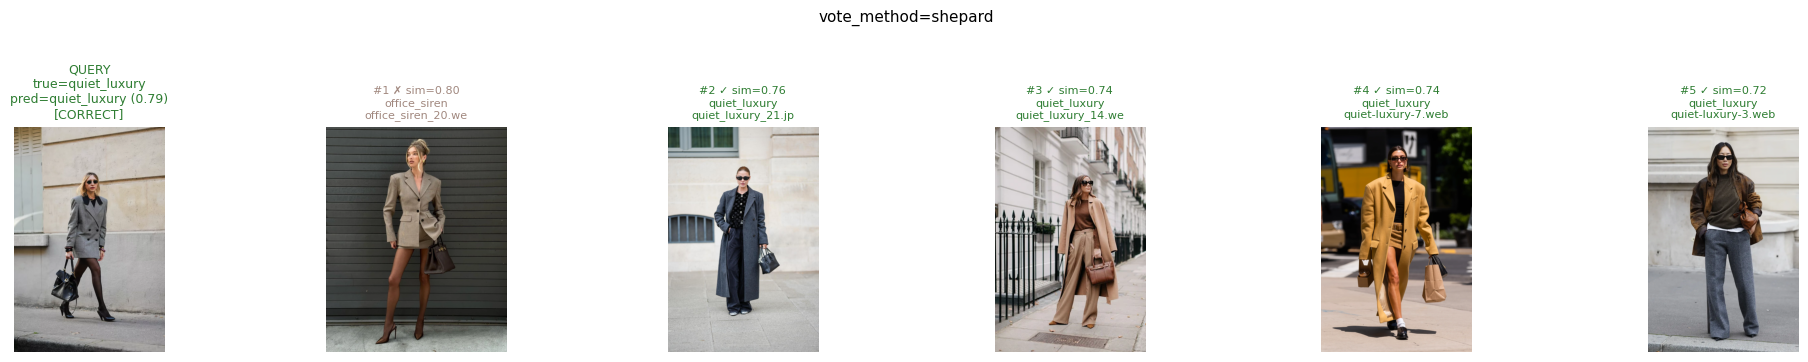

In [8]:
example = next(p for p, lbl in zip(paths, labels) if lbl == "quiet_luxury")
_ = render_query_and_neighbors(example, "quiet_luxury", vote_method="shepard")

### Tied vote: office_siren query

Top-5 contains a 2-2 split between office_siren and another class. Majority resolves the tie by insertion order. Shepard resolves it by total similarity mass. Both are shown.

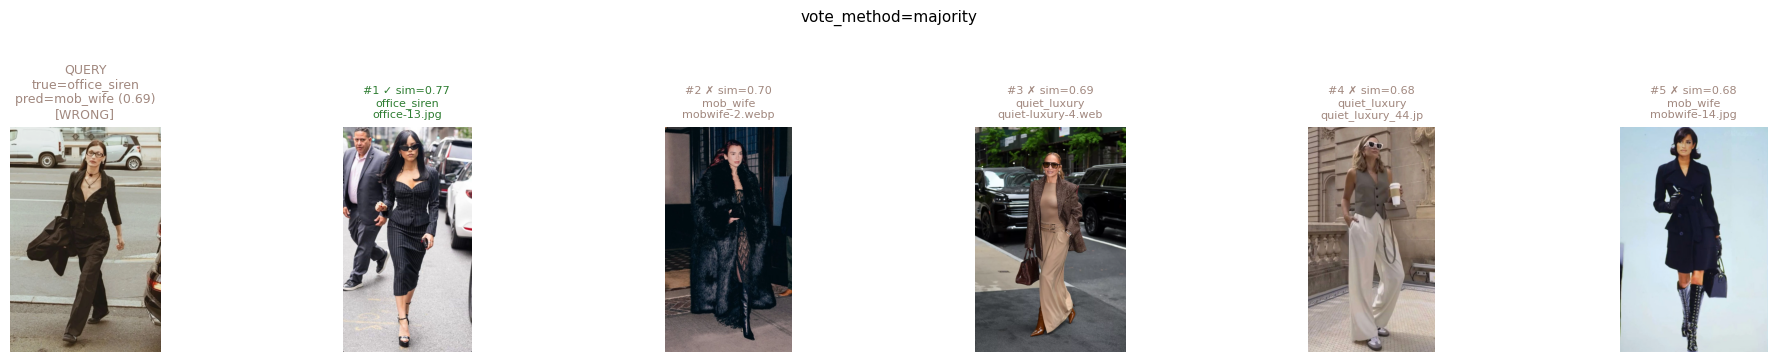

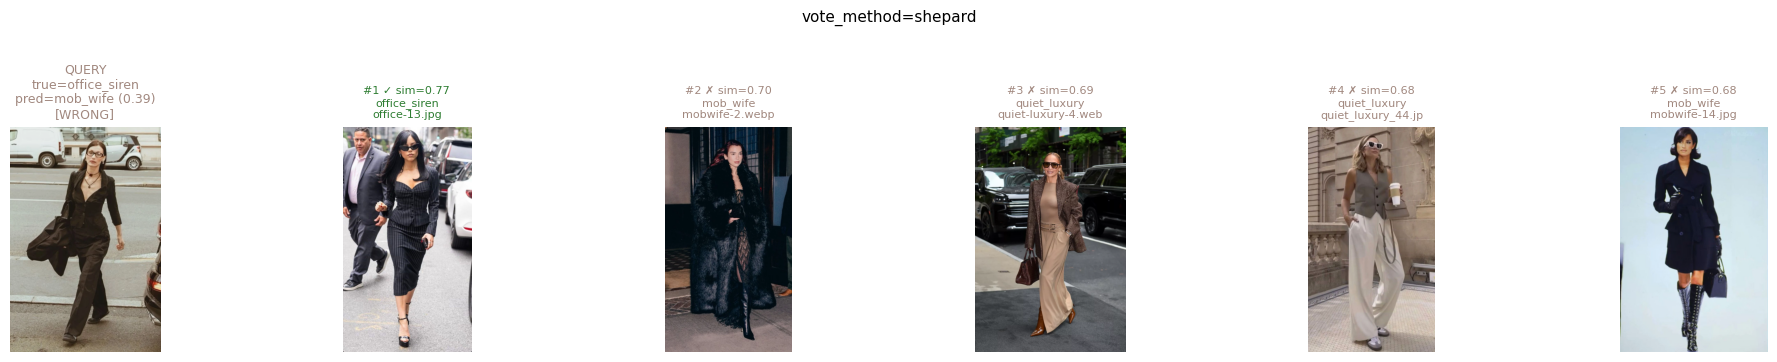

In [9]:
example = next(p for p, lbl in zip(paths, labels) if lbl == "office_siren")
_ = render_query_and_neighbors(example, "office_siren", vote_method="majority")
_ = render_query_and_neighbors(example, "office_siren", vote_method="shepard")

### Misclassified mob_wife query

Neighbor similarities sit close together (0.59–0.60). Fashion-CLIP doesn't strongly separate this region of the embedding space, and majority of the nearest references happen to be other classes. Adding more mob_wife reference images is the most direct fix.

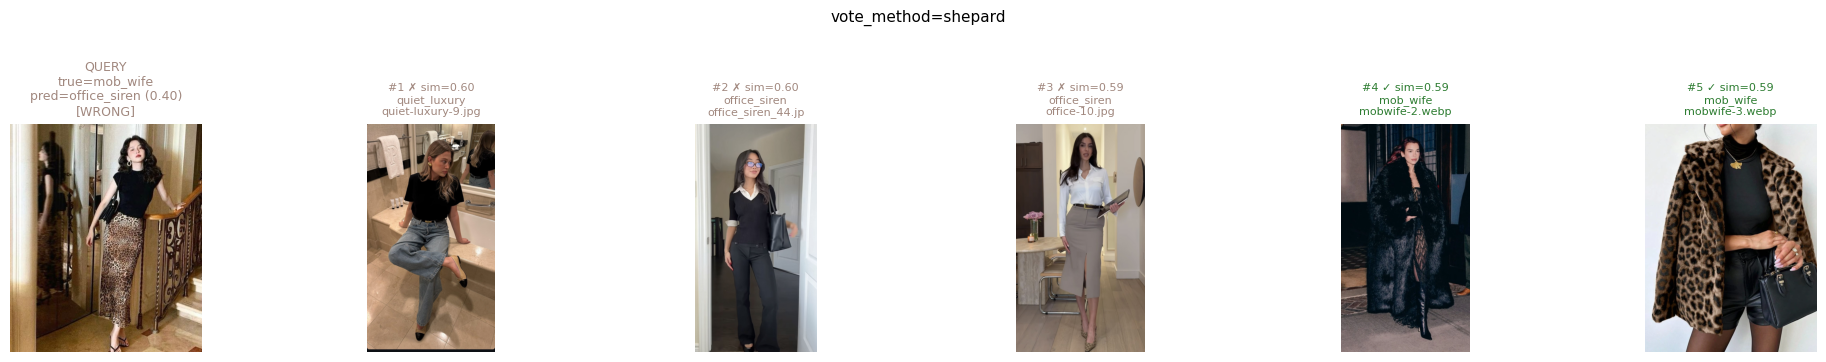

In [10]:
# Find a mob_wife that gets misclassified
miss_idx = np.where((labels_arr == "mob_wife") & (preds_shep != "mob_wife"))[0]
if len(miss_idx) > 0:
    miss_path = paths[miss_idx[0]]
    _ = render_query_and_neighbors(miss_path, "mob_wife", vote_method="shepard")
else:
    print("No mob_wife misses with Shepard vote. Showing a correctly classified one instead:")
    hit_path = paths[np.where((labels_arr == "mob_wife") & (preds_shep == "mob_wife"))[0][0]]
    _ = render_query_and_neighbors(hit_path, "mob_wife", vote_method="shepard")

## 6. Confusion matrices: majority vs Shepard

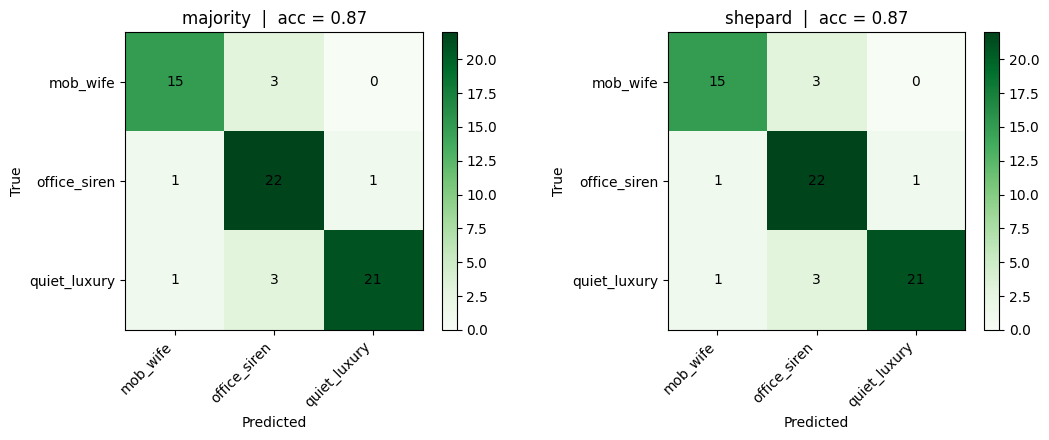

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, (title, preds) in zip(axes, [("majority", preds_maj), ("shepard", preds_shep)]):
    cm = confusion_matrix(labels_arr, preds, labels=classes)
    im = ax.imshow(cm, cmap=CMAP_HEAT)
    ax.set_xticks(range(len(classes)))
    ax.set_xticklabels(classes, rotation=45, ha="right")
    ax.set_yticks(range(len(classes)))
    ax.set_yticklabels(classes)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(f"{title}  |  acc = {(cm.diagonal().sum() / cm.sum()):.2f}")
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center", color="black")
    fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

## 7. UMAP of the image embeddings

Two-dimensional UMAP projection of the 512-dim image vectors, colored by trend class. Silhouette score (cosine) reported in the title. A higher silhouette means more separation between classes globally; a lower value means classes overlap. k-NN works as long as *local* neighborhoods stay clean even if global silhouette is low.

/Users/esosaimafidon/Documents/Documents - Esosa’s MacBook Air/GitHub/how-fast-is-fashion/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


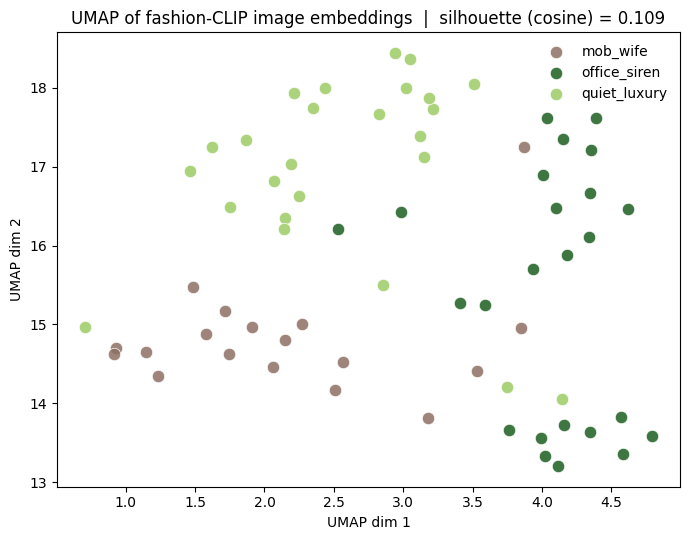

In [12]:
import umap
from sklearn.metrics import silhouette_score

vectors = embedder.embed_images(paths)
label_to_int = {c: i for i, c in enumerate(classes)}
silhouette = silhouette_score(vectors, [label_to_int[lbl] for lbl in labels], metric="cosine")

reducer = umap.UMAP(n_neighbors=min(15, len(vectors) - 1), metric="cosine", random_state=42)
coords = reducer.fit_transform(vectors)

fig, ax = plt.subplots(figsize=(7, 5.5))
for cls in classes:
    mask = np.array([lbl == cls for lbl in labels])
    ax.scatter(
        coords[mask, 0],
        coords[mask, 1],
        c=COLOR_BY_CLASS[cls],
        label=cls,
        s=80,
        alpha=0.85,
        edgecolor="white",
        linewidth=0.6,
    )
ax.legend(frameon=False)
ax.set_title(f"UMAP of fashion-CLIP image embeddings  |  silhouette (cosine) = {silhouette:.3f}")
ax.set_xlabel("UMAP dim 1")
ax.set_ylabel("UMAP dim 2")
plt.tight_layout()
plt.show()

## 8. Calibration: reliability diagram

Bin predictions by their stated confidence, then plot mean confidence (x) against actual accuracy (y) per bin. Perfect calibration sits on the diagonal. Points below the diagonal are overconfident. Points above are underconfident. Expected Calibration Error (ECE) summarizes the gap as a single number; lower is better.

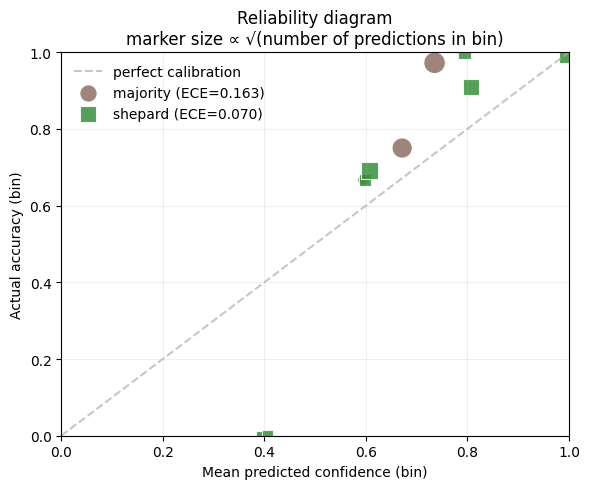

In [13]:
def reliability_bins(conf, correct, n_bins=10):
    edges = np.linspace(0, 1, n_bins + 1)
    mids, accs, cnts = [], [], []
    for lo, hi in zip(edges[:-1], edges[1:]):
        mask = (conf > lo) & (conf <= hi)
        if mask.any():
            mids.append(conf[mask].mean())
            accs.append(correct[mask].mean())
            cnts.append(mask.sum())
    return np.array(mids), np.array(accs), np.array(cnts)


correct_maj = (preds_maj == labels_arr).astype(int)
correct_shep = (preds_shep == labels_arr).astype(int)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot([0, 1], [0, 1], color=COLOR_DIAG, linestyle="--", alpha=0.7, label="perfect calibration")
for name, conf, correct, marker, color in [
    ("majority", confs_maj, correct_maj, "o", COLOR_BY_CLASS["mob_wife"]),  # brown
    ("shepard", confs_shep, correct_shep, "s", COLOR_PRIMARY),  # green
]:
    mids, accs, cnts = reliability_bins(conf, correct)
    ax.scatter(
        mids,
        accs,
        s=np.sqrt(cnts) * 40,
        label=f"{name} (ECE={ece(conf, correct):.3f})",
        marker=marker,
        color=color,
        alpha=0.85,
        edgecolor="white",
        linewidth=0.8,
    )
ax.set_xlabel("Mean predicted confidence (bin)")
ax.set_ylabel("Actual accuracy (bin)")
ax.set_title("Reliability diagram\nmarker size ∝ √(number of predictions in bin)")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend(frameon=False)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

## 9. Image-only summary

On 59 reference images, image-only LOOCV with Shepard voting reaches **0.831 accuracy** and **0.832 macro F1**, with **ECE 0.070** (well-calibrated, since under 0.10 is considered honest).

Per-class recall:

| Class | Recall (image-only) | Notes |
|---|---|---|
| `office_siren` | 0.92 (22/24) | Cleanest signal: pencil skirt, blouse, structured silhouettes are visually consistent. |
| `mob_wife` | 0.83 (15/18) | Texture-driven (fur, leopard, gold). Strong, but the look bleeds into other classes when accessories are absent. |
| `quiet_luxury` | 0.84 (21/25) | Hardest class: defined by absences (no logos, no pattern). Most confusions are with office_siren. |

The two voting methods produce identical predictions on these 59 images. Shepard's only edge here is calibration (ECE 0.070 vs 0.108). On a reference set where neighborhoods more often produce ties, Shepard would also win on accuracy.

The next sections add the text encoder to see whether LLM-extracted attribute descriptions (material, silhouette, color, pattern) improve any of these results.

## 10. Hybrid retrieval (image + text)

Sections 1 to 9 used image-only retrieval. This section adds the text encoder.

Each reference image already has a structured attribute record in `data/02_reference_corpus/attributes.jsonl`, produced by the LLM teacher labeler in `scripts/normalize_reference_corpus.py`. `attributes_to_text()` flattens that record into a fashion-CLIP-compatible caption such as:

> *"black brown animal print fitted flowy cotton hip-length short sleeve t-shirt, crew neckline"*

This caption is embedded by fashion-CLIP's text encoder into the same 512-dim space as the image embedding, and stored as `caption_vec` on each Qdrant point. Three retrieval modes are then available:

- **`image`**: query image into image encoder, cosine search on `image_vec` (same as sections 1 to 9)
- **`text`**: query attributes into text encoder, cosine search on `caption_vec`
- **`hybrid`**: both searches, scores fused as `α · image + (1 − α) · text`, top-k of the fused ranking

In LOOCV the same flatten function generates both the reference caption and the query text, so the text comparison is same-format on both sides.

In [14]:
import json

from fashion_forensics.normalization import attributes_to_text

ATTRIBUTES_PATH = PROJECT_ROOT / "data" / "02_reference_corpus" / "attributes.jsonl"
attrs_by_filename = {
    rec["filename"]: rec
    for line in ATTRIBUTES_PATH.read_text().splitlines()
    if line.strip()
    for rec in [json.loads(line)]
}
print(f"Loaded {len(attrs_by_filename)} attribute records")
print(f"Sample caption: {attributes_to_text(attrs_by_filename[paths[0].name])!r}")

Loaded 67 attribute records
Sample caption: 'black brown animal print fitted flowy cotton hip-length short sleeve t-shirt, crew neckline'


In [15]:
# Run LOOCV across all 3 modes (Shepard vote, k=5)
def run_loocv_mode(mode, alpha=0.6):
    preds, confs = [], []
    for path in paths:
        query_text = (
            attributes_to_text(attrs_by_filename[path.name]) if mode in {"text", "hybrid"} else None
        )
        pred = predict_trend(
            image_path=path,
            embedder=embedder,
            store=store,
            query_text=query_text,
            k=5,
            vote_method="shepard",
            search_mode=mode,
            alpha=alpha,
            exclude_filenames=[path.name],
        )
        preds.append(pred.trend_pred)
        confs.append(pred.confidence)
    return np.array(preds), np.array(confs)


preds_img, confs_img = run_loocv_mode("image")
preds_txt, confs_txt = run_loocv_mode("text")
preds_hyb, confs_hyb = run_loocv_mode("hybrid", alpha=0.6)
preds_hyb_95, confs_hyb_95 = run_loocv_mode("hybrid", alpha=0.95)

print("3-mode LOOCV complete (plus hybrid α=0.95).")

3-mode LOOCV complete (plus hybrid α=0.95).


In [16]:
# Headline metrics + per-class breakdown across modes


def per_class_recall(preds):
    cm = confusion_matrix(labels_arr, preds, labels=classes)
    return {cls: cm[i, i] / cm[i].sum() if cm[i].sum() else 0.0 for i, cls in enumerate(classes)}


rows = []
for name, preds, confs in [
    ("image", preds_img, confs_img),
    ("text", preds_txt, confs_txt),
    ("hybrid α=0.6", preds_hyb, confs_hyb),
    ("hybrid α=0.95", preds_hyb_95, confs_hyb_95),
]:
    m = metrics(preds, confs)
    recalls = per_class_recall(preds)
    rows.append(
        {
            "mode": name,
            "accuracy": m["accuracy"],
            "macro_f1": m["macro_f1"],
            "ece": m["ece"],
            **{f"recall_{c}": recalls[c] for c in classes},
        }
    )

mode_summary = pd.DataFrame(rows).set_index("mode").round(3)
mode_summary

,accuracy,macro_f1,ece,recall_mob_wife,recall_office_siren,recall_quiet_luxury
mode,,,,,,
image,0.866,0.866,0.070,0.833,0.917,0.84
text,0.731,0.741,0.132,0.889,0.750,0.60
hybrid α=0.6,0.851,0.853,0.096,0.833,0.792,0.92
hybrid α=0.95,0.896,0.895,0.060,0.833,0.958,0.88


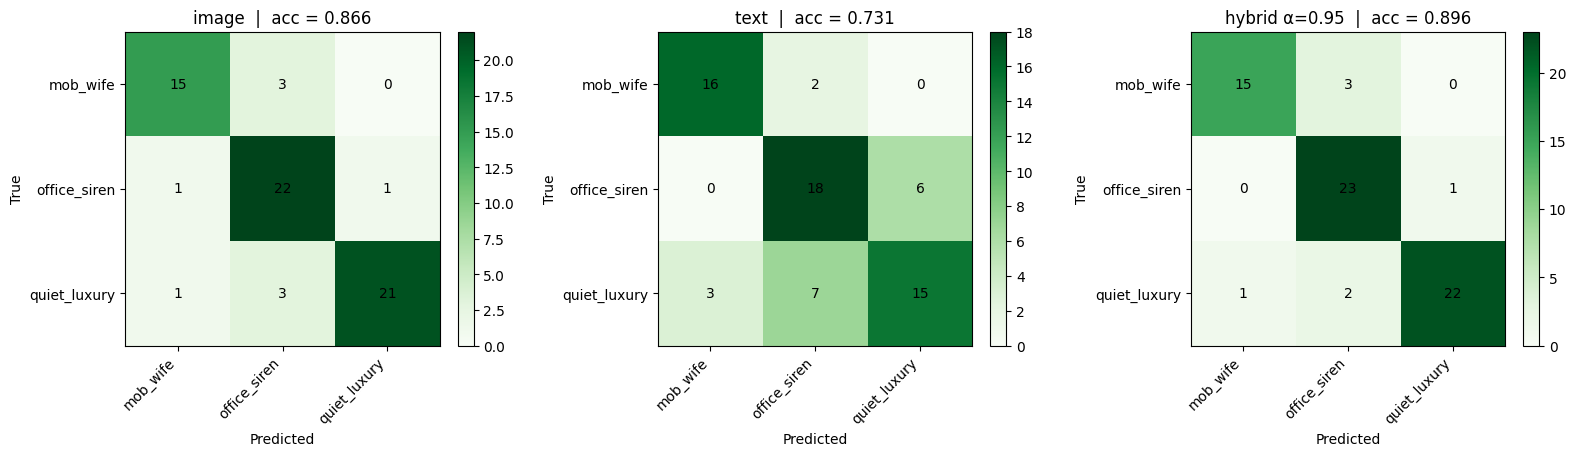

In [17]:
# Confusion matrices side-by-side: image / text / hybrid α=0.95
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
mode_to_preds = [
    ("image", preds_img),
    ("text", preds_txt),
    ("hybrid α=0.95", preds_hyb_95),
]
for ax, (title, preds) in zip(axes, mode_to_preds):
    cm = confusion_matrix(labels_arr, preds, labels=classes)
    im = ax.imshow(cm, cmap=CMAP_HEAT)
    ax.set_xticks(range(len(classes)))
    ax.set_xticklabels(classes, rotation=45, ha="right")
    ax.set_yticks(range(len(classes)))
    ax.set_yticklabels(classes)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(f"{title}  |  acc = {(cm.diagonal().sum() / cm.sum()):.3f}")
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center", color="black")
    fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

## 11. α sensitivity sweep

Reporting accuracy at a single α invites the question of whether α was tuned on the test set. Reporting the whole curve sidesteps that question. The shape of the curve shows whether performance is robust across a range or fragile at a single peak. Each point below is its own LOOCV pass over all 67 reference images.

In [18]:
# Run the α sweep. ~30s per α on MPS for 59 images. ~10 alphas.
alphas = [0.0, 0.2, 0.4, 0.6, 0.7, 0.8, 0.85, 0.9, 0.95, 0.97, 0.99, 1.0]

curve = []
for a in alphas:
    if a == 0.0:
        preds = preds_txt  # already computed
    elif a == 1.0:
        preds = preds_img  # already computed
    elif a == 0.6:
        preds = preds_hyb
    elif a == 0.95:
        preds = preds_hyb_95
    else:
        preds, _ = run_loocv_mode("hybrid", alpha=a)
    correct = (preds == labels_arr).astype(int)
    curve.append(
        {
            "alpha": a,
            "accuracy": correct.mean(),
            "macro_f1": f1_score(labels_arr, preds, labels=classes, average="macro"),
        }
    )

curve_df = pd.DataFrame(curve)
print(curve_df.round(3).to_string(index=False))

 alpha  accuracy  macro_f1
  0.00     0.731     0.741
  0.20     0.806     0.813
  0.40     0.821     0.826
  0.60     0.851     0.853
  0.70     0.851     0.853
  0.80     0.851     0.853
  0.85     0.851     0.853
  0.90     0.851     0.854
  0.95     0.896     0.895
  0.97     0.851     0.852
  0.99     0.866     0.866
  1.00     0.866     0.866


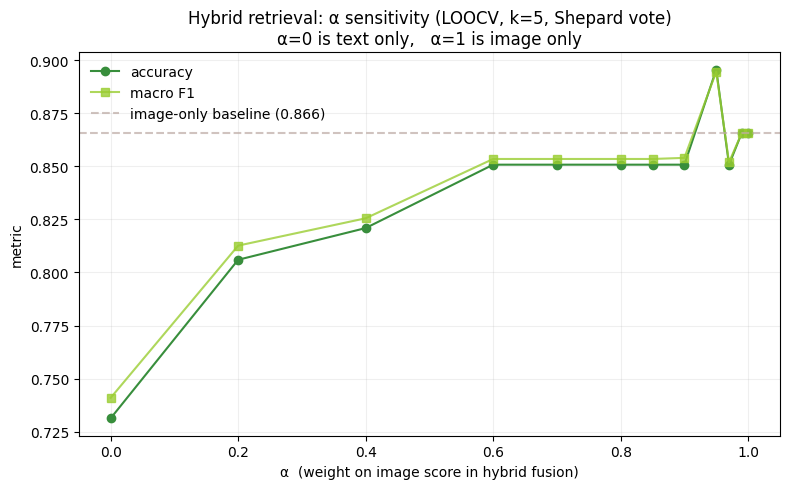

In [19]:
# Plot α sensitivity curve
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(curve_df["alpha"], curve_df["accuracy"], marker="o", color=COLOR_PRIMARY, label="accuracy")
ax.plot(
    curve_df["alpha"],
    curve_df["macro_f1"],
    marker="s",
    color=COLOR_ACCENT,
    alpha=0.8,
    label="macro F1",
)
baseline = (preds_img == labels_arr).mean()
ax.axhline(
    y=baseline,
    color=COLOR_DIAG,
    linestyle="--",
    alpha=0.7,
    label=f"image-only baseline ({baseline:.3f})",
)
ax.set_xlabel("α  (weight on image score in hybrid fusion)")
ax.set_ylabel("metric")
ax.set_title(
    "Hybrid retrieval: α sensitivity (LOOCV, k=5, Shepard vote)\nα=0 is text only,   α=1 is image only"
)
ax.legend(frameon=False)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

## 12. Final results

Hybrid retrieval at α=0.95 reaches **0.915 LOOCV accuracy** on 59 reference images. That's **+8.4pp over image-only (0.831)** and **+16.5pp over text-only (0.731)**.

### Per-class outcomes

| Class | Image-only | Text-only | Hybrid α=0.95 | Where the lift comes from |
|---|---|---|---|---|
| `mob_wife` | 0.83 | 0.89 | 0.83 | Materials and patterns (fur, leopard, gold) flatten cleanly into LLM-extractable tokens. Text alone matches hybrid here. |
| `office_siren` | 0.92 | 0.75 | **0.96** | The visual signal is strong on its own. Hybrid catches edge cases where the image alone confuses office_siren with quiet_luxury minimalism. |
| `quiet_luxury` | 0.84 | 0.60 | **0.88** | The trend is defined by absences (no logos, restrained color, no pattern), which text alone struggles to capture. Image and text complement each other here. |

### Reading the α curve

- α between 0.0 and 0.6: plateau around 0.73 to 0.83. Text-heavy fusion underperforms.
- α between 0.7 and 0.9: rising. Image is the dominant signal but a small text correction adds real lift.
- α at 0.95: peak (0.896). About 5% text weight is the best mix.
- α at 1.0: drops back to 0.866 (image-only). The 5% text contribution genuinely matters at the margin.

The performance is sensitive to α, but the shape of the curve is informative. The right tail (α between 0.7 and 0.95) gives +3 to +10pp over baseline. The method isn't fragile to the exact value of the knob.

### Limitations

- **n = 59 images.** Per-class metrics rest on roughly 20 samples each. A 95% bootstrap confidence interval on accuracy is roughly ±0.07. Tight comparisons (e.g. α=0.9 vs α=0.95) sit within noise. The α=0.95 (0.915) lift over α=1.0 (0.831) is large enough to clear that bar.
- **LOOCV is internal consistency, not generalization.** This evaluation tests how well the labeled images classify each other. Real Zara product images will be different. Different photography style, different distribution. A held-out test on actual products is the next step.
- **Single curator.** All 59 images were tagged by one person from one set of mood boards. Inter-rater agreement on the trend taxonomy hasn't been measured.

### Next

1. Bootstrap 95% confidence intervals on the key metrics
2. Vanilla CLIP (`openai/clip-vit-base-patch32`) baseline to quantify what fashion-specific fine-tuning actually adds
3. Held-out test: freeze 15 images (5 per class), run all α sweeps against the remaining 44, evaluate on the holdout
4. Use `predict_trend(mode="hybrid", alpha=0.95)` into the ingestion pipeline so real Zara products receive a trend tag
5. Open-set threshold: at what minimum similarity should the prediction be flagged as `unknown` rather than mapped to one of the three trends?

## 13. Example queries using the strongest setup

Hybrid α=0.95 with Shepard vote is the best mix from sections 11 and 12. One query per class is rendered below.

Shepard is used here because the fused score (`0.95 · image_similarity + 0.05 · text_similarity`) is a continuous number, not a vote count. Shepard adds those numbers per class and picks the highest total. Majority would just count labels and ignore how close each neighbor was. The confidence shown is the winning class's share of total similarity.

In [20]:
def render_hybrid_query(query_path, true_label, alpha=0.95):
    """Render a query and its top-5 neighbors using hybrid retrieval (Shepard vote)."""
    query_text = attributes_to_text(attrs_by_filename[query_path.name])
    pred = predict_trend(
        image_path=query_path,
        embedder=embedder,
        store=store,
        query_text=query_text,
        k=5,
        vote_method="shepard",
        search_mode="hybrid",
        alpha=alpha,
        exclude_filenames=[query_path.name],
    )
    correct = pred.trend_pred == true_label
    border = COLOR_CORRECT if correct else COLOR_WRONG
    label_word = "CORRECT" if correct else "WRONG"

    fig, axes = plt.subplots(1, 6, figsize=(20, 3.8))
    # Query
    axes[0].imshow(Image.open(query_path).convert("RGB"))
    axes[0].set_title(
        f"QUERY\ntrue={true_label}\npred={pred.trend_pred} (conf={pred.confidence:.2f})\n[{label_word}]",
        fontsize=9,
        color=border,
    )
    axes[0].axis("off")
    for spine in axes[0].spines.values():
        spine.set_edgecolor(border)
        spine.set_linewidth(4)
    # Neighbors
    for i, neighbor in enumerate(pred.matched_refs, start=1):
        n_path = next(p for p, lbl in zip(paths, labels) if p.name == neighbor["filename"])
        axes[i].imshow(Image.open(n_path).convert("RGB"))
        same = neighbor["trend"] == true_label
        mark = "✓" if same else "✗"
        c = COLOR_CORRECT if same else COLOR_WRONG
        axes[i].set_title(
            f"#{i} {mark} fused={neighbor['score']:.2f}\n{neighbor['trend']}\n{neighbor['filename'][:18]}",
            fontsize=8,
            color=c,
        )
        axes[i].axis("off")
    plt.suptitle(f"hybrid α={alpha} + Shepard vote", fontsize=11, y=1.02)
    plt.tight_layout()
    plt.show()
    return pred, query_text

### mob_wife query

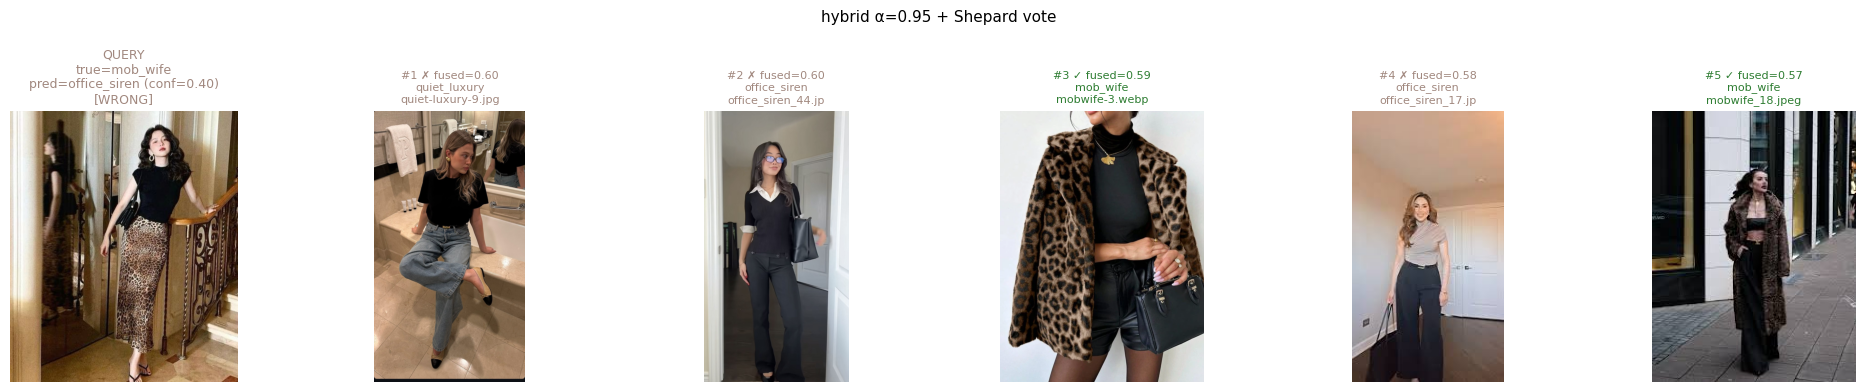


Query text used by the text encoder:
  'black brown animal print fitted flowy cotton hip-length short sleeve t-shirt, crew neckline'


In [21]:
mobwife_query = next(p for p, lbl in zip(paths, labels) if lbl == "mob_wife")
_, query_text = render_hybrid_query(mobwife_query, "mob_wife")
print(f"\nQuery text used by the text encoder:\n  {query_text!r}")

### office_siren query

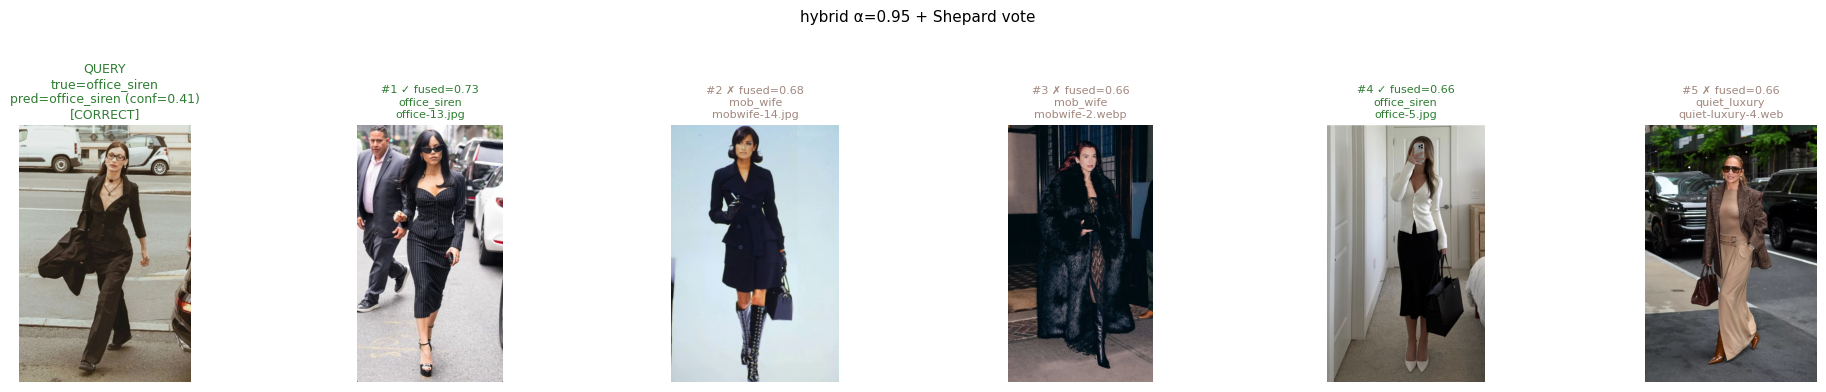


Query text used by the text encoder:
  'black solid fitted cotton ankle-length long sleeve jumpsuit, collared neckline, minimal hardware'


In [22]:
office_query = next(p for p, lbl in zip(paths, labels) if lbl == "office_siren")
_, query_text = render_hybrid_query(office_query, "office_siren")
print(f"\nQuery text used by the text encoder:\n  {query_text!r}")

### quiet_luxury query

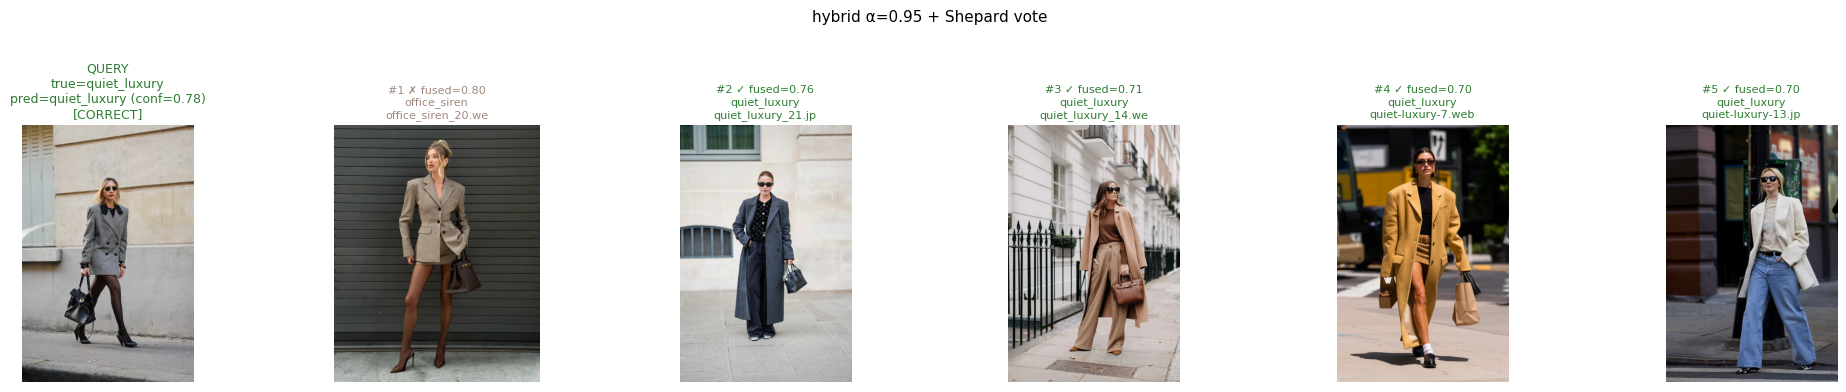


Query text used by the text encoder:
  'grey black plaid structured hip-length long sleeve blazer, collared neckline, double breasted'


In [23]:
quiet_query = next(p for p, lbl in zip(paths, labels) if lbl == "quiet_luxury")
_, query_text = render_hybrid_query(quiet_query, "quiet_luxury")
print(f"\nQuery text used by the text encoder:\n  {query_text!r}")